# Synthetic Array Data Simulator Utilities

## Theory

**Why simulate array data?**
- Lets you test and debug array processing (beamforming, DOA estimation, array filtering) with known ground-truth
- Allows you to control SNR, frequency, angle, and sensor configuration

**How does it work?**
- A plane wave at frequency $f$ arrives from angle $\theta$ (deg)
- Each array element receives a phase-delayed version of the wave
- Add noise for realism

**General formula for time delay at element $n$:**
$$
\tau_n = n \cdot d \cdot \sin(\theta) / c
$$
- $d$: spacing between elements (meters)
- $c$: wave speed (e.g., 1500 m/s for sound in water)

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulate_array_signals(n_elements, element_spacing, angle_deg, freq, snr_db, fs, duration, sound_speed=1500):
    """Simulate signals received at each element of a linear array for a plane wave."""
    t = np.arange(0, duration, 1/fs)
    theta_rad = np.deg2rad(angle_deg)
    array_pos = np.arange(n_elements) * element_spacing
    delays = array_pos * np.sin(theta_rad) / sound_speed
    clean_signals = np.array([np.sin(2*np.pi*freq*(t - delay)) for delay in delays])
    # Compute required noise std for desired SNR (power ratio)
    signal_power = np.mean(clean_signals**2)
    noise_power = signal_power / (10**(snr_db/10))
    noise = np.random.randn(*clean_signals.shape) * np.sqrt(noise_power)
    noisy_signals = clean_signals + noise
    return t, clean_signals, noisy_signals


### Demo: Simulate Array for Target at 30 Degrees

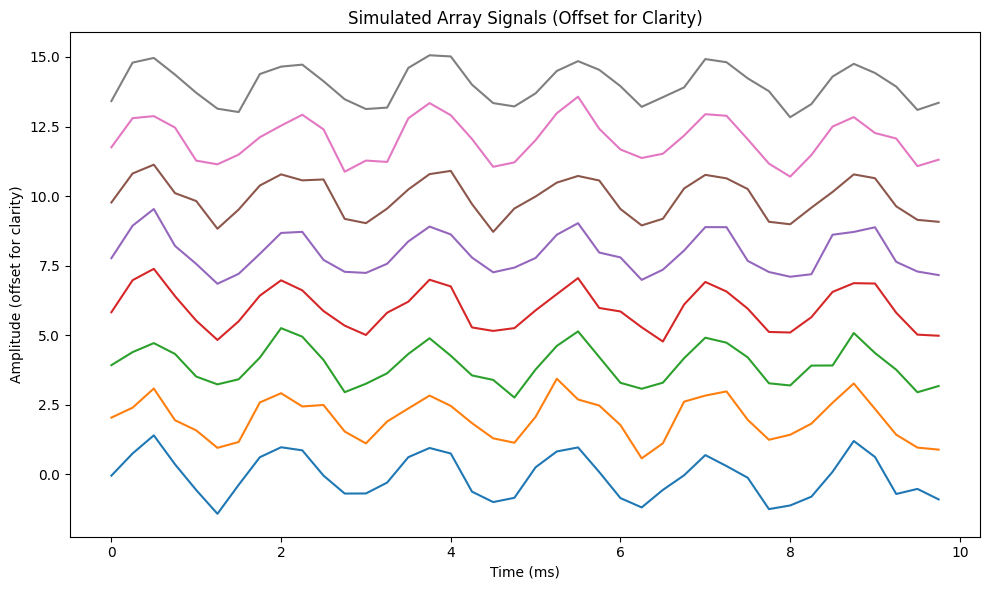

In [3]:
fs = 4000
duration = 0.01
n_elements = 8
element_spacing = 0.025  # 2.5 cm
angle_deg = 30
freq = 600  # Hz
snr_db = 10  # dB

t, clean, noisy = simulate_array_signals(n_elements, element_spacing, angle_deg, freq, snr_db, fs, duration)
import numpy as np
plt.figure(figsize=(10,6))
for i in range(n_elements):
    plt.plot(t*1e3, noisy[i]+i*2, label=f'Element {i+1} (noisy)')
plt.title('Simulated Array Signals (Offset for Clarity)')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (offset for clarity)')
plt.tight_layout()
plt.show()


---
## Usage Tips
- Change `angle_deg` to simulate target at any direction
- Use different `freq`, `snr_db`, `element_spacing`, `n_elements` for realistic or stress-test scenarios
- Use as input to beamforming, detection, or direction-of-arrival pipelines

**Indispensable for reproducible DSP and sonar algorithm development!**
